In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

In [2]:
path = "C:/Users/kelechi/Documents/Data Analytics/Data Science Investigation Project/ICUDatasetProcessed/"
csvs = os.listdir(path)
csvs

['Attack.csv', 'environmentMonitoring.csv', 'patientMonitoring.csv']

In [3]:
files = {
    "Attack": "Attack.csv",
    "environmentMonitoring": "environmentMonitoring.csv",
    "patientMonitoring": "patientMonitoring.csv",
}
dfs = {key: pd.read_csv(os.path.join(path, filename)) for key, filename in files.items()}

In [4]:
for label, df in dfs.items():
    print(f"The shape of {label} data is: {df.shape}")

The shape of Attack data is: (80126, 52)
The shape of environmentMonitoring data is: (31758, 52)
The shape of patientMonitoring data is: (76810, 52)


In [5]:
df_list = []

for csv in csvs:
    print(f"Reading: {csv}")
    df = pd.read_csv(os.path.join(path, csv), low_memory=False)
    df.fillna(0, inplace=True)
    df_list.append(df)

df = pd.concat(df_list, ignore_index=True)
print("Final shape:", df.shape)

Reading: Attack.csv
Reading: environmentMonitoring.csv
Reading: patientMonitoring.csv
Final shape: (188694, 52)


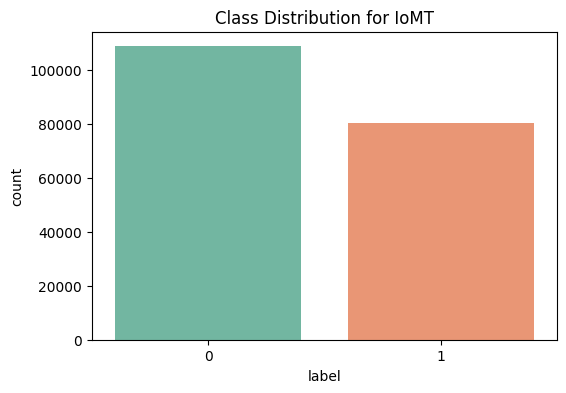

In [6]:
# Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label', palette='Set2')
plt.title("Class Distribution for IoMT")
plt.show()


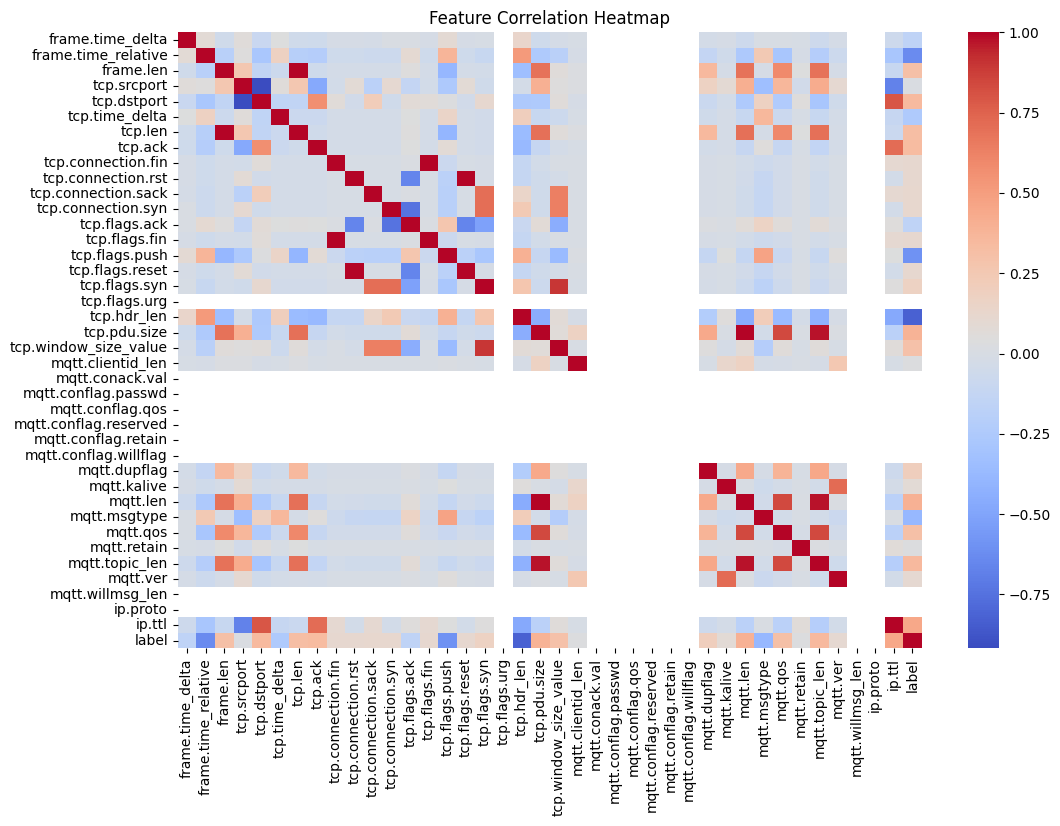

In [7]:
# Correlation Heatmap
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [8]:
# Drop unnecessary features
drop_feats = ['ip.src', 'ip.dst', 'tcp.srcport', 'tcp.dstport','mqtt.topic', 'mqtt.msg', 'tcp.payload',
              'mqtt.clientid', 'mqtt.conflags', 'mqtt.conack.flags', 'class']
df.drop(columns=[col for col in drop_feats if col in df.columns], inplace=True)
df.shape

(188694, 41)

In [9]:
# Select features
selected_feats = ['frame.time_delta', 'tcp.time_delta', 'tcp.flags.ack', 'tcp.flags.push', 'tcp.flags.reset',
                  'mqtt.hdrflags', 'mqtt.msgtype', 'mqtt.qos', 'mqtt.retain', 'mqtt.ver', 'label']

In [10]:
df = df[selected_feats]
df['mqtt.hdrflags'] = LabelEncoder().fit_transform(df['mqtt.hdrflags'])

In [11]:
X = df.drop('label', axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [12]:
# Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [13]:
# Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [14]:
# Evaluation
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32589
           1       1.00      1.00      1.00     24020

    accuracy                           1.00     56609
   macro avg       1.00      1.00      1.00     56609
weighted avg       1.00      1.00      1.00     56609

ROC-AUC: 0.9995588855513303


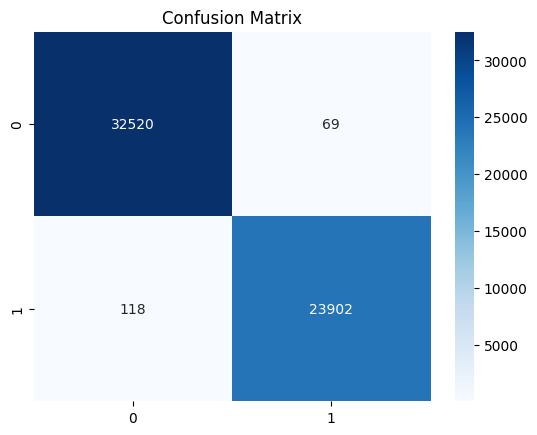

In [15]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

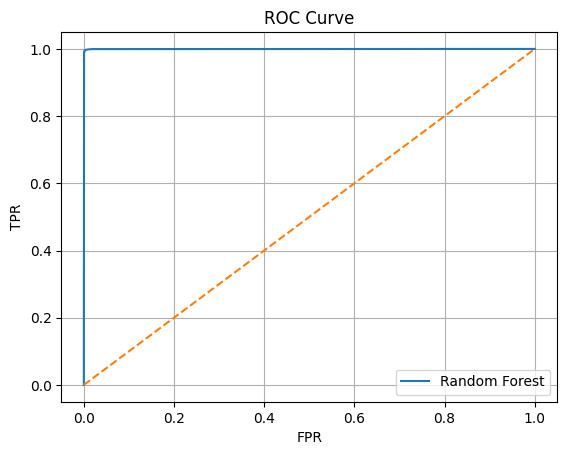

In [16]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label='Random Forest')
plt.plot([0, 1], [0, 1], '--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid()
plt.show()

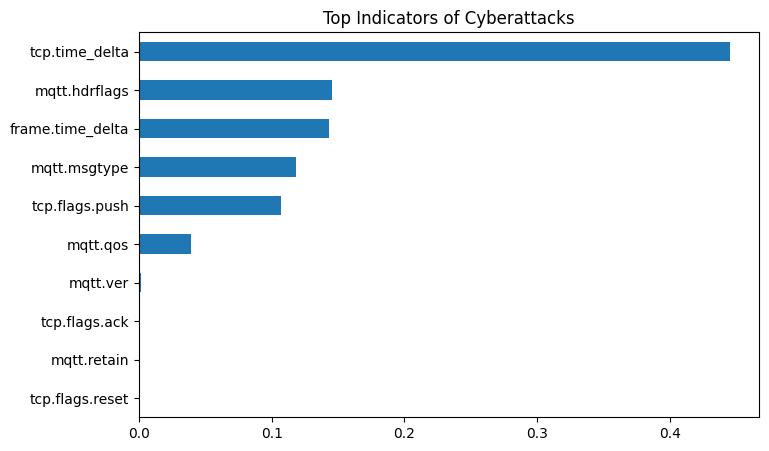

In [17]:
# Feature Importances
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
feat_imp.plot(kind='barh', figsize=(8,5), title="Top Indicators of Cyberattacks")
plt.show()